# Car Price Prediction with Machine Learning

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn

---

### A note on the dataset

This notebook is built to work with the **"Vehicle dataset from CarDekho"** on Kaggle (`name`, `year`, `selling_price`, `km_driven`, `fuel`, `seller_type`, `transmission`, `owner`).

Kaggle isn't reachable from the environment this notebook was authored in, so a **synthetic dataset with the exact same schema and realistic price relationships** (age → depreciation, mileage → price drop, brand tier, fuel/transmission/owner premiums, plus injected messiness: inconsistent casing, nulls, duplicates, outliers) was generated instead, so every cleaning/EDA/modeling step below has real work to do.

**To use the real data:** download `CAR DETAILS FROM CAR DEKHO.csv` (or similar) from Kaggle and replace the `pd.read_csv(...)` call in the next section with the path to that file — no other code changes are required, since the column names match.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the dataset

If you have downloaded the real CarDekho CSV from Kaggle, just point `DATA_PATH` at it -- the column
names (`name, year, selling_price, km_driven, fuel, seller_type, transmission, owner`) match exactly,
so no other code needs to change.


In [3]:
DATA_PATH = "car_data.csv"  # <- swap for the real Kaggle CSV path if you have one

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(10)


Shape: (3060, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti Dzire,2022,343900.0,87658.0,Diesel,Dealer,Manual,First Owner
1,Toyota Etios,2007,114000.0,120438.0,Diesel,NaN,Manual,First Owner
2,Toyota Fortuner,2013,281500.0,88268.0,Petrol,Dealer,Automatic,Second Owner
3,Toyota Glanza,2007,128800.0,132821.0,Petrol,Individual,Manual,First Owner
4,Tata Tiago,2008,85600.0,85685.0,Diesel,Individual,Manual,NaN
5,Ford EcoSport,2021,484600.0,97552.0,Petrol,Individual,Manual,First Owner
6,Renault Triber,2016,148600.0,113785.0,Petrol,Individual,Manual,First Owner
7,Maruti Baleno,2023,454400.0,78867.0,Diesel,Dealer,Manual,Test Drive Car
8,Honda WR-V,2013,214900.0,91748.0,Petrol,Dealer,Manual,First Owner
9,Audi A4,2005,207300.0,193575.0,CNG,Dealer,Automatic,Fourth & Above Owner


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           3060 non-null   str    
 1   year           3060 non-null   int64  
 2   selling_price  3000 non-null   float64
 3   km_driven      2999 non-null   float64
 4   fuel           2999 non-null   str    
 5   seller_type    2999 non-null   str    
 6   transmission   3060 non-null   str    
 7   owner          2998 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 191.4 KB


In [7]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,3060,62,Skoda Superb,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,3060.0,NaN,NaN,NaN,2013.971569,5.515662,2005.0,2009.0,2014.0,2019.0,2023.0
selling_price,3000.0,NaN,NaN,NaN,443696.533333,591577.197697,32300.0,118950.0,235300.0,477425.0,4710900.0
km_driven,2999.0,NaN,NaN,NaN,107269.630544,150019.903642,500.0,72457.5,99771.0,129251.0,4110275.0
fuel,2999,18,Petrol,1335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,2999,12,Individual,1536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,3060,8,Manual,2114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,2998,5,First Owner,1661,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

Steps:
1. Standardize categorical text (strip whitespace, consistent casing) — e.g. `" petrol "`, `"PETROL"`, `"Petrol"` should all become one value.
2. Check and handle missing values.
3. Remove duplicate rows.
4. Deal with unrealistic outliers (e.g. absurd `km_driven` values from data-entry errors).


In [8]:
# --- 2.1 Inspect raw categorical inconsistency ---
for col in ["fuel", "seller_type", "transmission", "owner"]:
    print(col, "->", df[col].dropna().unique()[:10])
    print()


fuel -> <StringArray>
[  'Diesel',   'Petrol',      'CNG',      'LPG',      'lpg', ' Diesel ',
   'PETROL',      'cng',   'DIESEL', ' Petrol ']
Length: 10, dtype: str

seller_type -> <StringArray>
[            'Dealer',         'Individual', ' Trustmark Dealer ',
         'individual',             'dealer',   'Trustmark Dealer',
         'INDIVIDUAL',             'DEALER',       ' Individual ',
   'trustmark dealer']
Length: 10, dtype: str

transmission -> <StringArray>
[     'Manual',   'Automatic',      'MANUAL',      'manual', ' Automatic ',
    ' Manual ',   'AUTOMATIC',   'automatic']
Length: 8, dtype: str

owner -> <StringArray>
[         'First Owner',         'Second Owner',       'Test Drive Car',
 'Fourth & Above Owner',          'Third Owner']
Length: 5, dtype: str



In [9]:
# --- 2.2 Standardize categorical text ---
categorical_cols = ["fuel", "seller_type", "transmission", "owner"]

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    # str() turns real NaNs into the string "Nan" -- convert those back to actual NaN
    df.loc[df[col] == "Nan", col] = np.nan

print("Cleaned unique values:")
for col in categorical_cols:
    print(col, "->", sorted(df[col].dropna().unique()))


Cleaned unique values:
fuel -> ['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol']
seller_type -> ['Dealer', 'Individual', 'Trustmark Dealer']
transmission -> ['Automatic', 'Manual']
owner -> ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']


In [10]:
# --- 2.3 Missing values ---
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()} / {len(df)}")


Missing values per column:
name              0
year              0
selling_price    60
km_driven        61
fuel             61
seller_type      61
transmission      0
owner            62
dtype: int64

Rows with at least one missing value: 298 / 3060


In [11]:
# We drop rows with missing values rather than impute, since the missing fraction
# per column is small (~2%) and this is a clean, defensible baseline. In a production
# setting you might instead impute (median for numeric, mode for categorical).
df = df.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df.shape)


Shape after dropping missing values: (2762, 8)


In [12]:
# --- 2.4 Duplicates ---
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Duplicate rows found: 54
Shape after removing duplicates: (2708, 8)


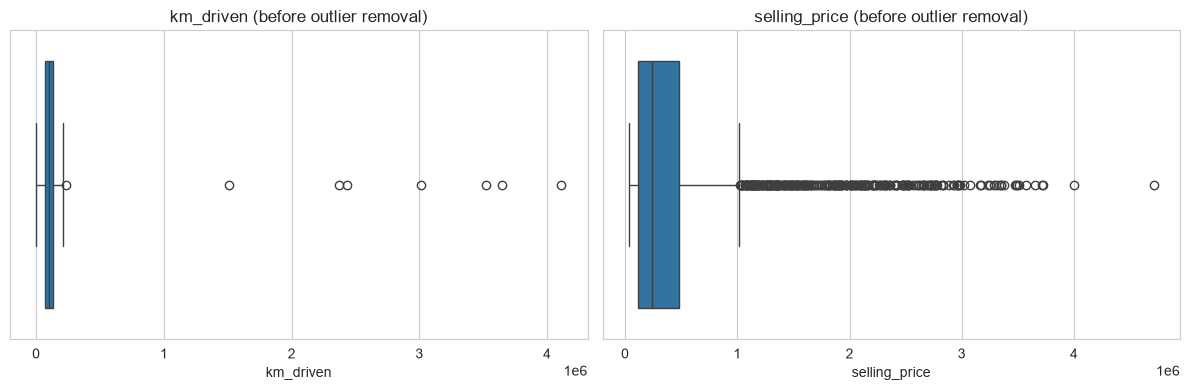

In [13]:
# --- 2.5 Outliers ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["km_driven"], ax=axes[0])
axes[0].set_title("km_driven (before outlier removal)")
sns.boxplot(x=df["selling_price"], ax=axes[1])
axes[1].set_title("selling_price (before outlier removal)")
plt.tight_layout()
plt.show()


In [14]:
# Cap km_driven at the 99th percentile to remove obvious data-entry errors
# (e.g. a car recorded with 25x the plausible mileage)
km_cap = df["km_driven"].quantile(0.99)
price_floor, price_cap = df["selling_price"].quantile([0.005, 0.995])

before = len(df)
df = df[(df["km_driven"] <= km_cap) &
        (df["selling_price"].between(price_floor, price_cap))].reset_index(drop=True)

print(f"Removed {before - len(df)} outlier rows. Final shape: {df.shape}")


Removed 56 outlier rows. Final shape: (2652, 8)


## 3. Feature Engineering

* **`car_age`** — derived from `year` (dataset reference year assumed to be 2024).
* **`brand`** — extracted from the first word of the `name` column (e.g. `"Maruti Swift Dzire VDI"` → `"Maruti"`).


In [15]:
REFERENCE_YEAR = 2024

df["car_age"] = REFERENCE_YEAR - df["year"]
df["brand"] = df["name"].str.split().str[0]

print("Brands found:", df["brand"].nunique())
df[["name", "brand", "year", "car_age"]].head(10)


Brands found: 15


,name,brand,year,car_age
0,Maruti Dzire,Maruti,2022,2
1,Toyota Fortuner,Toyota,2013,11
2,Toyota Glanza,Toyota,2007,17
3,Ford EcoSport,Ford,2021,3
4,Renault Triber,Renault,2016,8
5,Maruti Baleno,Maruti,2023,1
6,Honda WR-V,Honda,2013,11
7,Audi A4,Audi,2005,19
8,Nissan Terrano,Nissan,2010,14
9,Chevrolet Cruze,Chevrolet,2020,4


In [16]:
# name/year are no longer needed once we have brand + car_age
df_model = df.drop(columns=["name", "year"])
df_model.head()


,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,343900.0,87658.0,Diesel,Dealer,Manual,First Owner,2,Maruti
1,281500.0,88268.0,Petrol,Dealer,Automatic,Second Owner,11,Toyota
2,128800.0,132821.0,Petrol,Individual,Manual,First Owner,17,Toyota
3,484600.0,97552.0,Petrol,Individual,Manual,First Owner,3,Ford
4,148600.0,113785.0,Petrol,Individual,Manual,First Owner,8,Renault


## 4. Exploratory Data Analysis (EDA)


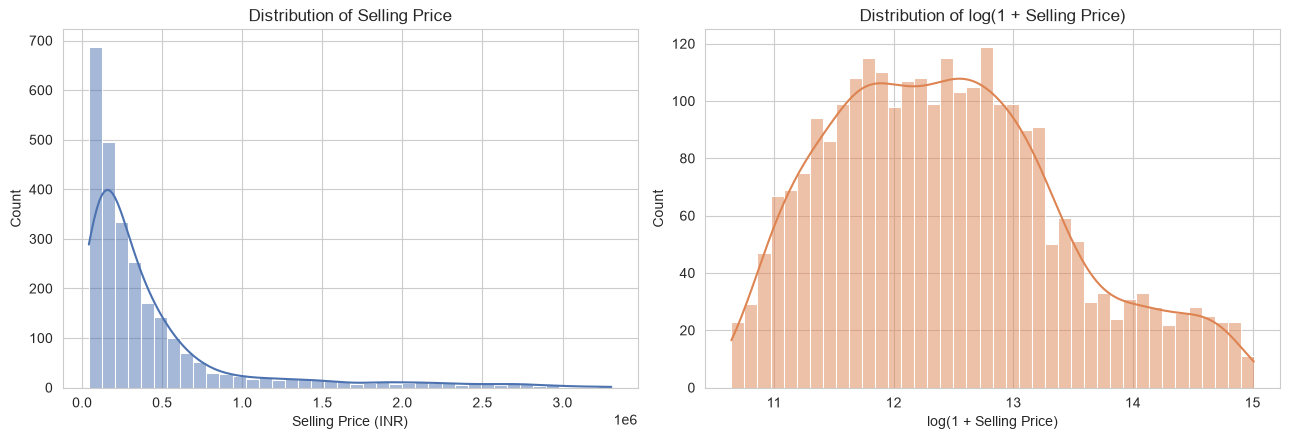

In [17]:
# --- Distribution of selling prices ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_model["selling_price"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Selling Price")
axes[0].set_xlabel("Selling Price (INR)")

sns.histplot(np.log1p(df_model["selling_price"]), bins=40, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of log(1 + Selling Price)")
axes[1].set_xlabel("log(1 + Selling Price)")
plt.tight_layout()
plt.show()


C:\Users\VENKAT\AppData\Local\Temp\ipykernel_11300\3746753012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="fuel", y="selling_price", order=order, palette="Set2")


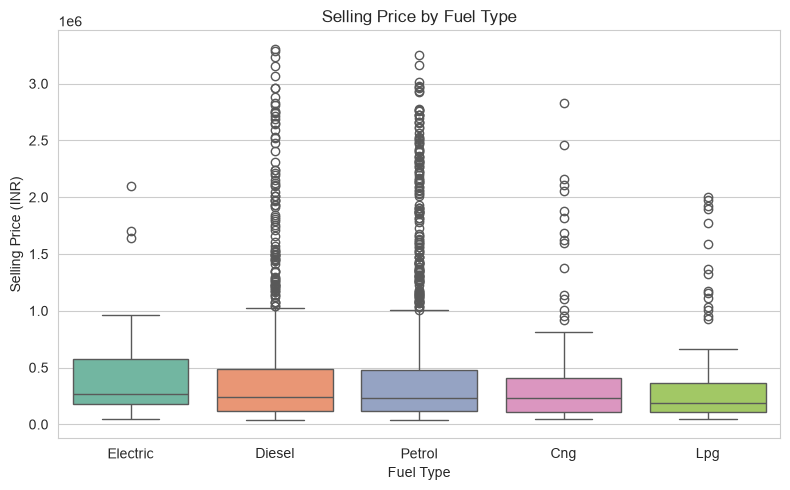

In [18]:
# --- Price vs fuel type ---
plt.figure(figsize=(8, 5))
order = df_model.groupby("fuel")["selling_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df_model, x="fuel", y="selling_price", order=order, palette="Set2")
plt.title("Selling Price by Fuel Type")
plt.ylabel("Selling Price (INR)")
plt.xlabel("Fuel Type")
plt.tight_layout()
plt.show()


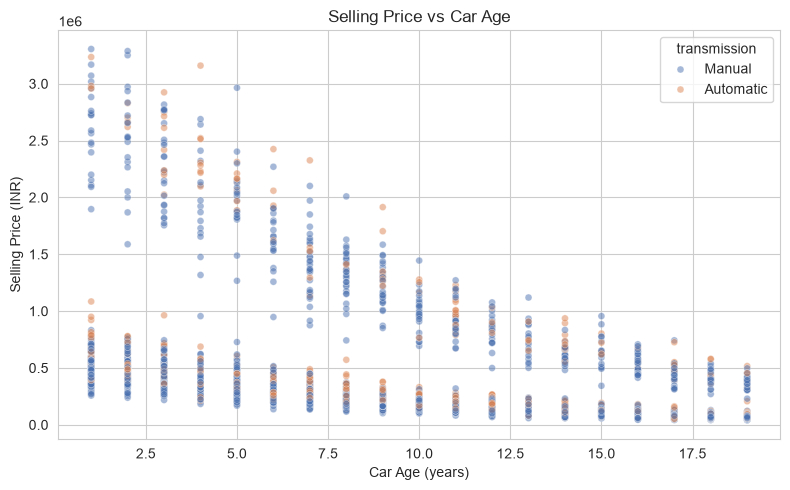

In [19]:
# --- Price vs car age ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="car_age", y="selling_price", hue="transmission",
                 alpha=0.5, s=25, palette="deep")
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (INR)")
plt.tight_layout()
plt.show()


C:\Users\VENKAT\AppData\Local\Temp\ipykernel_11300\3032924513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="transmission", y="selling_price", ax=axes[0], palette="Set3")
C:\Users\VENKAT\AppData\Local\Temp\ipykernel_11300\3032924513.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[1], palette="viridis")


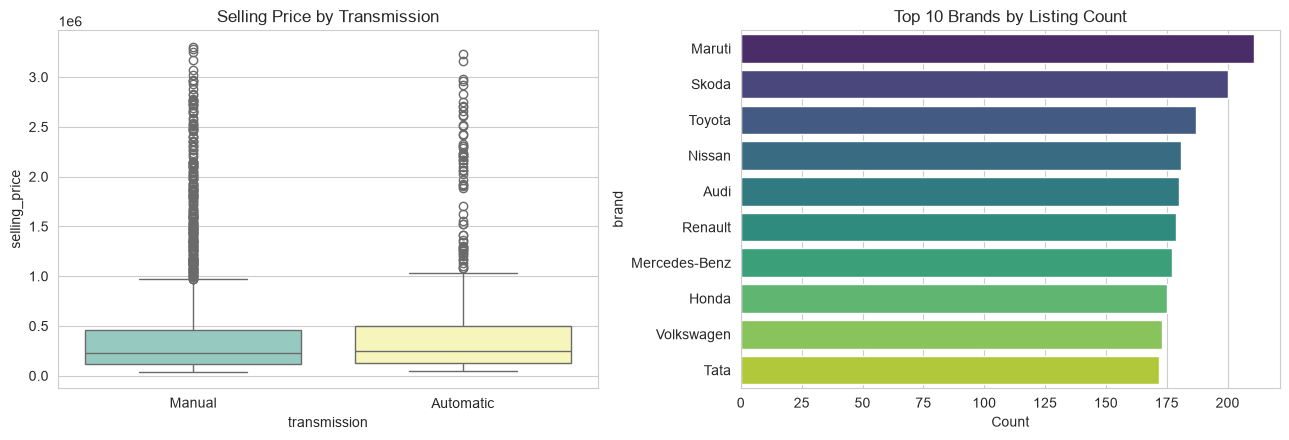

In [20]:
# --- A couple of bonus views: price by transmission, and top brands by count ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df_model, x="transmission", y="selling_price", ax=axes[0], palette="Set3")
axes[0].set_title("Selling Price by Transmission")

top_brands = df_model["brand"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[1], palette="viridis")
axes[1].set_title("Top 10 Brands by Listing Count")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.show()


## 5. Encode Categorical Variables

`brand`, `fuel`, `seller_type`, `transmission`, and `owner` are nominal categoricals with no natural order,
so **one-hot encoding** is used (`drop_first=True` to avoid the dummy-variable trap).


In [21]:
categorical_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (2652, 28)


,selling_price,km_driven,car_age,brand_BMW,brand_Chevrolet,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,...,fuel_Electric,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,343900.0,87658.0,2,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,281500.0,88268.0,11,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,128800.0,132821.0,17,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
3,484600.0,97552.0,3,False,False,True,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
4,148600.0,113785.0,8,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False


## 6. Feature Correlation Heatmap

(computed on the numeric + one-hot encoded feature set, restricted to the most informative columns for readability)


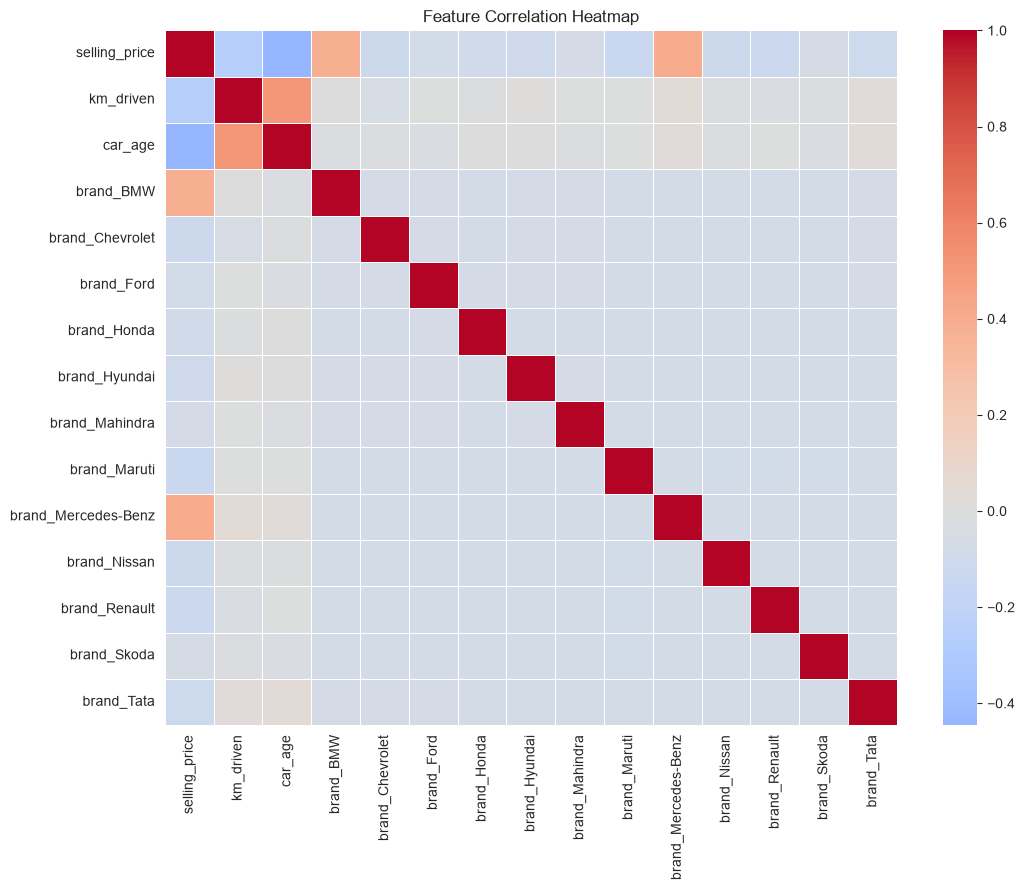

In [22]:
numeric_cols = ["selling_price", "km_driven", "car_age"]
top_dummy_cols = [c for c in df_encoded.columns
                   if c not in numeric_cols][:12]  # keep the heatmap readable

corr = df_encoded[numeric_cols + top_dummy_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [23]:
corr["selling_price"].sort_values(ascending=False)


selling_price          1.000000
brand_Mercedes-Benz    0.400188
brand_BMW              0.388046
brand_Skoda           -0.060646
brand_Mahindra        -0.064434
brand_Ford            -0.083910
brand_Honda           -0.085905
brand_Hyundai         -0.101434
brand_Tata            -0.114907
brand_Chevrolet       -0.118419
brand_Nissan          -0.119937
brand_Renault         -0.128464
brand_Maruti          -0.132984
km_driven             -0.254113
car_age               -0.445918
Name: selling_price, dtype: float64

## 7. Train / Test Split


In [24]:
X = df_encoded.drop(columns=["selling_price"])
y = df_encoded["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2121, 27)
Test shape: (531, 27)


## 8. Train Regression Models

Three models are trained and compared:
1. **Linear Regression** — simple, interpretable baseline.
2. **Random Forest Regressor** — ensemble of decision trees, captures non-linear relationships.
3. **Gradient Boosting Regressor** — sequential boosted trees, often strong on tabular data.


In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    ),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Linear Regression
Trained: Random Forest
Trained: Gradient Boosting


## 9. Model Evaluation

Metrics used:
* **MAE** (Mean Absolute Error) — average absolute rupee error, easy to interpret.
* **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily.
* **R²** — proportion of variance in price explained by the model.


In [26]:
results = []
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Random Forest,111147.670433,194855.656164,0.870634
1,Gradient Boosting,111413.229699,234314.912077,0.812934
2,Linear Regression,170959.016422,265699.375202,0.759467


C:\Users\VENKAT\AppData\Local\Temp\ipykernel_11300\4139112019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", palette="mako")


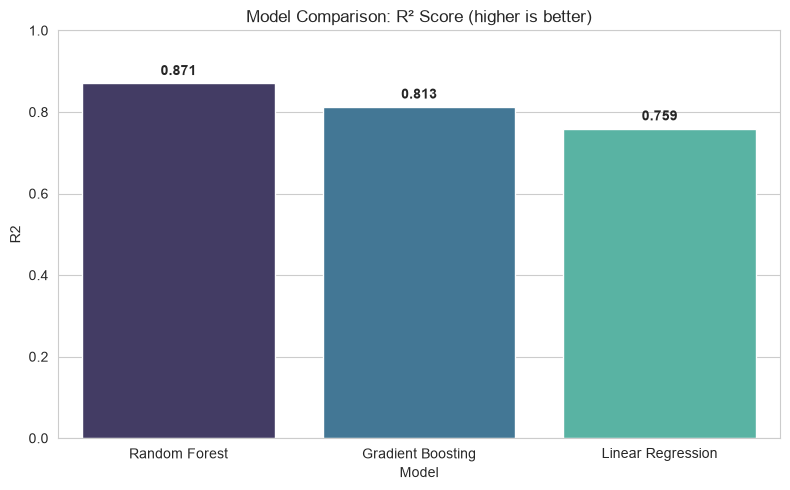

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2", palette="mako")
plt.title("Model Comparison: R\u00b2 Score (higher is better)")
plt.ylim(0, 1)
for i, v in enumerate(results_df["R2"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


In [29]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df.set_index("Model").loc[best_model_name])


Best performing model: Random Forest
MAE     111147.670433
RMSE    194855.656164
R2           0.870634
Name: Random Forest, dtype: float64


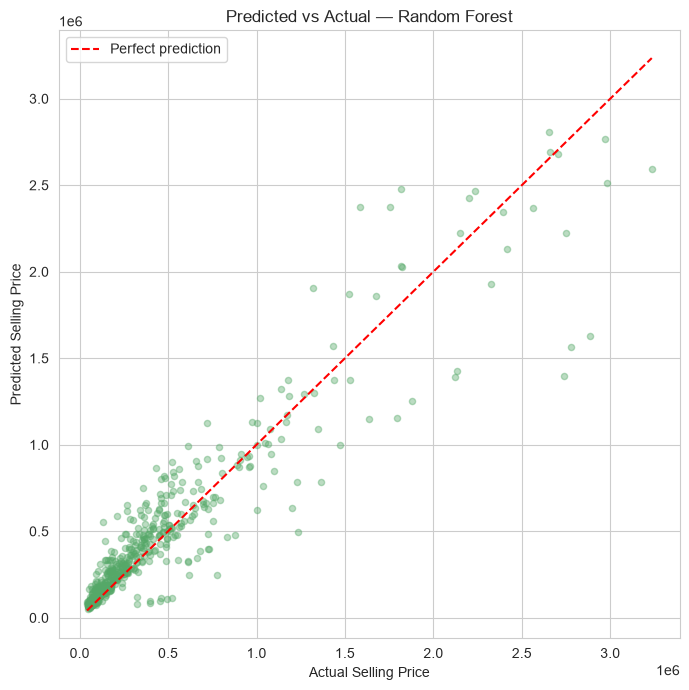

In [30]:
# Predicted vs Actual for the best model
best_preds = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.4, s=20, color="#55A868")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Feature Importance (Best Model)


C:\Users\VENKAT\AppData\Local\Temp\ipykernel_11300\3669086635.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette="rocket")


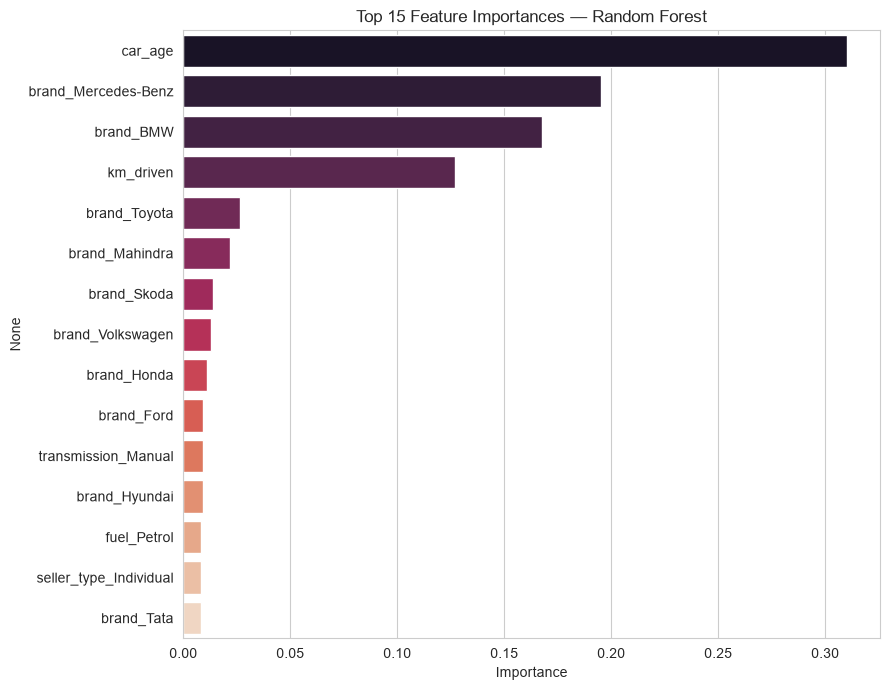

In [31]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns)
else:
    importances = None

if importances is not None:
    top_importances = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 7))
    sns.barplot(x=top_importances.values, y=top_importances.index, palette="rocket")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


## 11. Summary

* The dataset was cleaned (standardized categorical text, missing values dropped, duplicates removed, extreme outliers capped).
* `car_age` and `brand` were engineered from `year` and `name`.
* EDA showed selling price is right-skewed, strongly driven by **car age** (depreciation) and **km driven**, with a smaller effect from fuel type and transmission.
* All three models were evaluated with MAE, RMSE, and R²; the best model's predicted-vs-actual plot and feature importance chart are shown above.
* **Next steps to try:** log-transform the target, hyperparameter tuning (e.g. `GridSearchCV`), try `XGBoost`/`LightGBM`, add more granular brand tiers or model-specific features.
